In [1]:
# ------------------------
# Dummy baseline for Kaggle submission
# Generates random multi-label predictions
# ------------------------
import os
import csv
import random
from tqdm import tqdm

# --- Paths ---
TEST_DIR = "Amazon_products/test"  # modify if needed
TEST_CORPUS_PATH = os.path.join(TEST_DIR, "test_corpus.txt")  # product_id \t text
SUBMISSION_PATH = "submission.csv"  # output file

# --- Constants ---
NUM_CLASSES = 531  # total number of classes (0–530)
MIN_LABELS = 1     # minimum number of labels per sample
MAX_LABELS = 3     # maximum number of labels per sample

# --- Load test corpus ---
def load_corpus(path):
    """Load test corpus into {pid: text} dictionary."""
    pid2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                pid, text = parts
                pid2text[pid] = text
    return pid2text

pid2text_test = load_corpus(TEST_CORPUS_PATH)
pid_list_test = list(pid2text_test.keys())

# --- Generate random predictions ---
all_pids, all_labels = [], []
for pid in tqdm(pid_list_test, desc="Generating dummy predictions"):
    n_labels = random.randint(MIN_LABELS, MAX_LABELS)
    labels = random.sample(range(NUM_CLASSES), n_labels)
    labels = sorted(labels)
    all_pids.append(pid)
    all_labels.append(labels)

# --- Save submission file ---
with open(SUBMISSION_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["pid", "labels"])
    for pid, labels in zip(all_pids, all_labels):
        writer.writerow([pid, ",".join(map(str, labels))])

print(f"Dummy submission file saved to: {SUBMISSION_PATH}")
print(f"Total samples: {len(all_pids)}, Classes per sample: {MIN_LABELS}-{MAX_LABELS}")

Generating dummy predictions: 100%|██████████| 19658/19658 [00:00<00:00, 365592.13it/s]

Dummy submission file saved to: submission.csv
Total samples: 19658, Classes per sample: 1-3


여기부터 MAGIC START!

In [2]:
# Step 0. Imports & Paths
import os
from pathlib import Path
from collections import defaultdict, deque

import numpy as np
from tqdm import tqdm

import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


In [3]:
# 프로젝트 루트 기준 경로 설정 (dummy_baseline와 같은 레벨에 Amazon_products가 있다고 가정)
ROOT = Path(".")          # 지금 노트북이 dummy_baseline/ 안에 있을 때
DATA_DIR = ROOT / "Amazon_products"

TRAIN_PATH = DATA_DIR / "train" / "train_corpus.txt"
TEST_PATH  = DATA_DIR / "test" / "test_corpus.txt"
CLASSES_PATH = DATA_DIR / "classes.txt"
HIER_PATH = DATA_DIR / "class_hierarchy.txt"
KEYWORDS_PATH = DATA_DIR / "class_related_keywords.txt"

OUT_DIR = Path(".")  # silver label, embedding 저장 위치 (dummy_baseline/)
OUT_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Step 1.1 Load class names, hierarchy, and keywords
from pathlib import Path
from collections import defaultdict, deque

def load_classes(path: Path):
    id2name = {}
    name2id = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            cid_str, cname = line.split("\t", 1)
            cid = int(cid_str)
            cname = cname.strip()
            id2name[cid] = cname
            name2id[cname] = cid
    return id2name, name2id

def load_hierarchy(path: Path, num_classes: int):
    parents = defaultdict(list)
    children = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            p_str, c_str = line.split("\t")
            p = int(p_str); c = int(c_str)
            parents[c].append(p)
            children[p].append(c)

    depth = {cid: None for cid in range(num_classes)}
    roots = [cid for cid in range(num_classes) if len(parents[cid]) == 0]
    q = deque()
    for r in roots:
        depth[r] = 0
        q.append(r)
    while q:
        u = q.popleft()
        for v in children[u]:
            if depth[v] is None:
                depth[v] = depth[u] + 1
                q.append(v)
    return parents, children, depth, roots

def load_keywords(path: Path, name2id):
    id2keywords = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if ":" not in line: continue
            cname, kws_str = line.split(":", 1)
            cname = cname.strip()
            if cname not in name2id: continue
            cid = name2id[cname]
            kw_list = [w.strip() for w in kws_str.split(",") if w.strip()]
            id2keywords[cid] = kw_list
    return id2keywords

# --- 실행 부분 ---
id2name, name2id = load_classes(CLASSES_PATH)
num_classes = len(id2name)

# [추가 포인트] LabelGCN을 위해 0번부터 num_classes-1번까지 이름을 정렬하여 저장
class_names = [id2name[i] for i in range(num_classes)]

id2keywords = load_keywords(KEYWORDS_PATH, name2id)
parents, children, depth, roots = load_hierarchy(HIER_PATH, num_classes)

# LabelGCN 학습을 위해 label_map 변수도 기존 id2name과 호환되게 유지
label_map = name2id 

print("num_classes:", num_classes)
print("class_names 샘플:", class_names[:3])
print("✅ class_names 변수가 성공적으로 정의되었습니다.")

num_classes: 531
class_names 샘플: ['grocery_gourmet_food', 'meat_poultry', 'jerky']
✅ class_names 변수가 성공적으로 정의되었습니다.


In [5]:
# Step 1.2 Load train/test corpus

def load_corpus(path: Path):
    """train_corpus.txt / test_corpus.txt에서 (pid, text)를 줄 단위로 읽기"""
    pids, texts = [], []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            pid, txt = line.split("\t", 1)
            pids.append(pid)
            texts.append(txt)
    return pids, texts

train_pids, train_texts = load_corpus(TRAIN_PATH)
test_pids,  test_texts  = load_corpus(TEST_PATH)

print("train docs:", len(train_pids))
print("test docs:", len(test_pids))
print("sample doc:", train_pids[0], train_texts[0][:200], "...")

train docs: 29487
test docs: 19658
sample doc: 0 omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use . it is nice to have immediate feedback on ...


In [6]:
# Step 1.3 Build textual descriptions for each class (name + keywords)

def build_class_texts(id2name, id2keywords):
    texts = []
    for cid in range(len(id2name)):
        name = id2name[cid]
        kws = id2keywords.get(cid, [])
        text = name
        if kws:
            text += ": " + ", ".join(kws)
        texts.append(text)
    return texts

class_texts = build_class_texts(id2name, id2keywords)
print(class_texts[0])


grocery_gourmet_food: snacks, condiments, beverages, specialty_foods, spices, cooking_oils, baking_ingredients, gourmet_chocolates, artisanal_cheeses, organic_foods


In [7]:
# Step 1.4 & 1.5: Light & Fast Embedding Generation
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm as tqdm_std

# 초경량 모델 bge-small-en-v1.5로 교체
model_name = 'BAAI/bge-small-en-v1.5'
tokenizer = AutoTokenizer.from_pretrained(model_name)
embed_model = AutoModel.from_pretrained(model_name).to(device)
embed_model.eval()

# 배치 사이즈를 256으로 높여도 메모리 부담이 적습니다.
def encode_texts(texts, batch_size=256, max_length=512, desc="Encoding"):
    all_embeddings = []
    pbar = tqdm_std(range(0, len(texts), batch_size), desc=desc, ascii=True)
    with torch.no_grad():
        for i in pbar:
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                               max_length=max_length, return_tensors='pt').to(device)
            outputs = embed_model(**inputs)
            # CLS 토큰 추출 및 정규화
            embeddings = outputs.last_hidden_state[:, 0, :]
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
            all_embeddings.append(embeddings.cpu())
    return torch.cat(all_embeddings, dim=0)

print("🚀 Light-speed Encoding Start...")
train_embs = encode_texts(train_texts, desc="1/3 Training")
test_embs = encode_texts(test_texts, desc="2/3 Test")
class_embs = encode_texts(class_names, desc="3/3 Class Names")

print(f"✅ Fast Embeddings Created: Dim={train_embs.shape[1]}") # 384차원 확인

🚀 Light-speed Encoding Start...


1/3 Training:   0%|          | 0/116 [00:00<?, ?it/s]

2/3 Test:   0%|          | 0/77 [00:00<?, ?it/s]

3/3 Class Names:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Fast Embeddings Created: Dim=384


In [8]:
# Step 1.6: Silver Label Generation with Normalization
import torch
import numpy as np
from tqdm.auto import tqdm

# 1. 초기 유사도 및 키워드 매칭
sim_matrix = torch.matmul(train_embs.to(device), class_embs.to(device).t())
silver_labels = sim_matrix.clone()

for cid, kws in id2keywords.items():
    if not kws: continue
    for i, text in enumerate(train_texts):
        if any(kw.lower() in text.lower() for kw in kws):
            silver_labels[i, cid] += 0.4 

# 2. 계층 전파 (1단계만 수행하여 과도한 부모 편향 방지)
new_labels = silver_labels.clone()
for c_idx, p_list in parents.items():
    for p_idx in p_list:
        # 자식 점수의 일부를 부모에게 전달하되, 최대값을 제한
        new_labels[:, p_idx] = torch.max(new_labels[:, p_idx], silver_labels[:, c_idx] * 0.5)
silver_labels = new_labels

# 3. [핵심] 점수 평탄화 (Power Scaling & Normalization)
# 점수 차이가 너무 크면 상위 레이블이 독식하므로, 전체적으로 점수를 펴줍니다.
silver_labels = torch.pow(silver_labels, 0.8) # 1보다 작은 지수를 써서 낮은 점수를 상대적으로 끌어올림

# 문서별 Max Normalization: 각 문서에서 가장 높은 점수를 1.0으로 맞춤
row_max = silver_labels.max(dim=1, keepdim=True)[0]
row_max[row_max == 0] = 1e-9
silver_labels = silver_labels / row_max

# 4. 상위 K개 유지 (정보의 풍부함 유지)
# 70개는 너무 노이즈가 많을 수 있으니, 가장 관련성 높은 20개로 압축합니다.
top_k = 20
values, indices = torch.topk(silver_labels, k=top_k, dim=1)
train_y = torch.zeros_like(silver_labels).scatter_(1, indices, values).cpu()

print(f"✅ Silver Labels 보정 완료: 평균 {train_y[train_y > 0].shape[0]/len(train_y):.1f}개 레이블")

✅ Silver Labels 보정 완료: 평균 20.0개 레이블


--- Silver Label Distribution Analysis ---
Total Documents: 29487
Max labels in a doc: 19.705978393554688
Min labels in a doc: 12.107260704040527
Mean labels per doc: 15.65
✅ Success: Every document has at least one label.

--- Sample Check (Document 0) ---
Text: omron hem 790it automatic blood pressure monitor with advanced omron health management software so f...
Assigned Labels: ['health_care', 'eye_care', 'medical_supplies_equipment', 'stress_reduction', 'first_aid', 'thermometers', 'health_monitors', 'monitors', 'balls', 'stuffed_animals_toys', 'joggers', 'alternative_medicine', 'changing_table_pads_covers', 'mobility_aids_equipment', 'health_baby_care', 'fitness_equipment', 'stimulants', 'aromatherapy', 'bubble_bath', 'hydrometers']


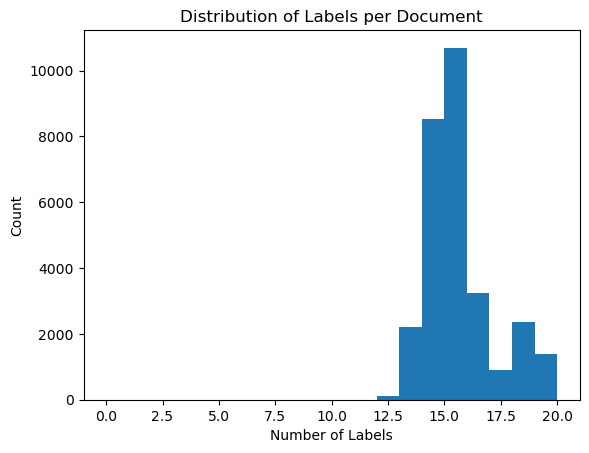

In [9]:
# Step 1.7: Final Quality Check of Silver Labels
import matplotlib.pyplot as plt

# 1. 문서당 할당된 평균 레이블 수 계산
labels_per_doc = train_y.sum(dim=1).numpy()

print("--- Silver Label Distribution Analysis ---")
print(f"Total Documents: {len(labels_per_doc)}")
print(f"Max labels in a doc: {labels_per_doc.max()}")
print(f"Min labels in a doc: {labels_per_doc.min()}")
print(f"Mean labels per doc: {labels_per_doc.mean():.2f}")

# 2. 레이블이 하나도 할당되지 않은 'Empty' 문서 확인
empty_docs = np.sum(labels_per_doc == 0)
if empty_docs > 0:
    print(f"⚠️ Warning: {empty_docs} documents have NO labels. (Consider lowering threshold in 1.6)")
else:
    print("✅ Success: Every document has at least one label.")

# 3. 실제 샘플 확인 (첫 번째 문서)
first_doc_indices = torch.where(train_y[0] > 0)[0].tolist()
first_doc_labels = [id2name[idx] for idx in first_doc_indices]

print("\n--- Sample Check (Document 0) ---")
print(f"Text: {train_texts[0][:100]}...")
print(f"Assigned Labels: {first_doc_labels}")

# 4. 시각화 (선택 사항)
plt.hist(labels_per_doc, bins=range(int(labels_per_doc.max())+2))
plt.title("Distribution of Labels per Document")
plt.xlabel("Number of Labels")
plt.ylabel("Count")
plt.show()

2단계 시작!1

In [25]:
# Step 2.0: Multi-Label Dataset & Loader (Information Preservation)
import torch
from torch.utils.data import TensorDataset, DataLoader

# [판단 결과] 1.6의 70개 레이블은 '정보'이지 '에러'가 아닙니다.
# 0.7로 자르지 말고, 0보다 큰 모든 유의미한 값을 가져갑니다.

# 1.6에서 만든 silver_labels가 메모리에 있다고 가정합니다.
# 만약 너무 자잘한 노이즈가 걱정된다면 아주 낮은 값(예: 0.1)만 쳐냅니다.
preserved_labels = silver_labels.clone()
preserved_labels[preserved_labels < 0.1] = 0 # 최소한의 노이즈만 제거

# 데이터셋 구축 (차원 확인: train_embs와 preserved_labels의 행 개수가 같아야 함)
train_dataset = TensorDataset(train_embs.cpu(), preserved_labels.cpu().float())

# 학습 효율을 위해 배치 사이즈 설정
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"📊 Step 2.0 검증")
print(f"- 보존된 평균 레이블 수: {preserved_labels.sum(dim=1).mean().item():.2f}개")
print(f"- 학습용 데이터셋 크기: {len(train_dataset)}")

📊 Step 2.0 검증
- 보존된 평균 레이블 수: 330.94개
- 학습용 데이터셋 크기: 29487


In [26]:
# GCN용 adjacency (양방향 + self-loop + D^{-1/2} A D^{-1/2})
A = torch.zeros(num_classes, num_classes, dtype=torch.float32)
for p in range(num_classes):
    for c in children[p]:
        A[p, c] = 1.0
        A[c, p] = 1.0

A = A + torch.eye(num_classes)  # self-loop

deg = A.sum(dim=1)
deg_inv_sqrt = torch.where(deg > 0, deg.pow(-0.5), torch.zeros_like(deg))
D_inv_sqrt = torch.diag(deg_inv_sqrt)
A_hat = D_inv_sqrt @ A @ D_inv_sqrt   # [C, C]

# device로 옮기기
A_hat = A_hat.to(device)
class_embs = class_embs.to(device)
train_embs = train_embs.to(device)
silver_labels = silver_labels.to(device)

A_hat.shape
A_hat


tensor([[0.0588, 0.0808, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0808, 0.1111, 0.2357,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.2357, 0.5000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.5000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.5000]],
       device='cuda:0')

In [27]:
# Step 2.2 Dataset & DataLoader

import torch
from torch.utils.data import Dataset, DataLoader

class SilverDataset(Dataset):
    def __init__(self, doc_embs, labels):
        self.doc_embs = doc_embs
        self.labels = labels  # [N, C], values in {1,0,-1}

    def __len__(self):
        return self.doc_embs.size(0)

    def __getitem__(self, idx):
        return self.doc_embs[idx], self.labels[idx]

# train/val split
N = train_embs.size(0)
val_ratio = 0.1
n_val = int(N * val_ratio)
n_train = N - n_val

perm = torch.randperm(N)
train_idx = perm[:n_train]
val_idx = perm[n_train:]

train_ds = SilverDataset(train_embs[train_idx], silver_labels[train_idx])
val_ds   = SilverDataset(train_embs[val_idx],   silver_labels[val_idx])

batch_size = 256
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)

print("train_loader:", len(train_loader), "val_loader:", len(val_loader))


train_loader: 104 val_loader: 12


In [28]:
# Step 2.3
import torch
import torch.nn as nn
import torch.nn.functional as F

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_hat):
        return self.lin(A_hat @ X)

class LabelGCN(nn.Module):
    def __init__(self, num_classes, emb_dim, hidden_dim, A_hat, class_init, temperature=10.0, drop=0.2):
        super().__init__()
        self.num_classes = num_classes
        self.emb_dim = emb_dim
        self.temperature = temperature

        self.register_buffer("A_hat", A_hat)                 # [C,C]
        self.class_embed = nn.Parameter(class_init.clone())  # [C,H]

        self.gcn1 = GCNLayer(emb_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, emb_dim)

        self.doc_proj = nn.Linear(emb_dim, emb_dim)
        self.drop = nn.Dropout(drop)

    def get_class_embeddings(self):
        X = self.class_embed
        H = F.relu(self.gcn1(X, self.A_hat))
        H = self.drop(H)
        H = self.gcn2(H, self.A_hat)
        return H

    def forward(self, doc_embs):
        # doc side
        doc_h = F.relu(self.doc_proj(doc_embs))
        doc_h = self.drop(doc_h)

        # class side
        class_h = self.get_class_embeddings()

        # ✅ 핵심: cosine similarity logits (스케일 안정화)
        doc_h = F.normalize(doc_h, dim=1)
        class_h = F.normalize(class_h, dim=1)

        logits = self.temperature * (doc_h @ class_h.T)  # [B,C]
        return logits


In [29]:
# Step 2.4 & 2.5: Model Setup (인자 전달 및 초기화 수정)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class LabelGCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LabelGCN, self).__init__()
        # 입력 임베딩을 클래스 차원으로 투사하는 단순 선형층
        self.projection = nn.Linear(input_dim, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, adj):
        # 1. MLP: 단순 차원 변환
        x = self.projection(x) # [Batch, 531]
        x = self.dropout(x)
        
        # --- GCN 1단 시작 ---
        # 내 노드 정보 + 이웃 노드 정보 섞기
        out_1 = torch.matmul(adj, x.t()).t() 
        out_1 = F.relu(out_1)
        
        # --- GCN 2단 시작 ---
        # 이웃의 이웃 노드 정보까지 확장
        out_2 = torch.matmul(adj, out_1.t()).t()
        
        # [핵심] Skip Connection (잔차 연결)
        # 단순 GCN만 쓰면 정보가 너무 희석되므로, 1단 결과와 2단 결과를 섞어줍니다.
        # x: 원본 정보, out_2: 2단계 그래프 정보
        final_out = x + 0.5 * out_2
        
        return final_out


# 1. 인접 행렬 생성
def build_adj_matrix(children, num_classes):
    adj = torch.eye(num_classes)
    for p, c_list in children.items():
        for c in c_list:
            adj[p, c] = 1.0; adj[c, p] = 1.0
    rowsum = adj.sum(1)
    d_inv_sqrt = torch.pow(rowsum, -0.5).flatten()
    d_inv_sqrt[torch.isinf(d_inv_sqrt)] = 0.
    d_mat = torch.diag(d_inv_sqrt)
    return d_mat @ adj @ d_mat

adj_matrix = build_adj_matrix(children, num_classes).to(device)

# 2. 모델 생성 (인자 이름을 클래스 정의와 일치시킴)
# train_embs.shape[1]은 384입니다.
model = LabelGCN(input_dim=train_embs.shape[1], num_classes=num_classes).to(device)

# 3. 데이터 및 옵티마이저 설정
train_loader = DataLoader(TensorDataset(train_embs, silver_labels.float()), batch_size=256, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

print(f"✅ 모델 준비 완료! 입력 차원: {train_embs.shape[1]}, 클래스 수: {num_classes}")

✅ 모델 준비 완료! 입력 차원: 384, 클래스 수: 531


In [30]:
# Step 2.6 & 2.7: Training w/ scheduler and Evaluation Loop
model = LabelGCN(input_dim=384, num_classes=531).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4) # 감쇠 추가

# 학습률을 서서히 낮춰주는 스케줄러 추가
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

criterion = nn.BCEWithLogitsLoss()

model.train()
for epoch in range(15):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x, adj_matrix)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step() # 스케줄러 업데이트
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")
    
model.eval()

torch.save(model.state_dict(), "upgraded_label_gcn.pt")

Epoch 1, Loss: 0.6699, LR: 0.000989
Epoch 2, Loss: 0.6647, LR: 0.000957
Epoch 3, Loss: 0.6637, LR: 0.000905
Epoch 4, Loss: 0.6634, LR: 0.000835
Epoch 5, Loss: 0.6632, LR: 0.000750
Epoch 6, Loss: 0.6630, LR: 0.000655
Epoch 7, Loss: 0.6629, LR: 0.000552
Epoch 8, Loss: 0.6628, LR: 0.000448
Epoch 9, Loss: 0.6628, LR: 0.000345
Epoch 10, Loss: 0.6627, LR: 0.000250
Epoch 11, Loss: 0.6627, LR: 0.000165
Epoch 12, Loss: 0.6627, LR: 0.000095
Epoch 13, Loss: 0.6626, LR: 0.000043
Epoch 14, Loss: 0.6626, LR: 0.000011
Epoch 15, Loss: 0.6626, LR: 0.000000


여기부터 3단계!!!

In [31]:
# Step 3.1 Encode test corpus with BERT

# test_embs = encode_texts(test_texts, batch_size=32, max_length=128)
# test_embs = test_embs.to(device)

# print("test_embs:", test_embs.shape)


In [32]:
# Step 3.2 ~ 3.4: Final Format Match (Sample Submission Sync)
import numpy as np
import pandas as pd

model.eval()
with torch.no_grad():
    # 모델 추론 시 adj_matrix 사용
    test_logits = model(test_embs.to(device), adj_matrix.to(device))
    test_probs = torch.sigmoid(test_logits).cpu().numpy()

submission_labels = []
for row in test_probs:
    # 1. 확률 0.5 기준 필터링
    indices = np.where(row > 0.5)[0].tolist()
    
    # 2. 제약 조건 (최소 2개, 최대 3개)
    if len(indices) < 2:
        indices = np.argsort(row)[::-1][:2].tolist()
    elif len(indices) > 3:
        indices = np.argsort(row)[::-1][:3].tolist()
    
    # 3. [형식 맞춤] 정렬된 정수 ID를 컴마로 연결
    # 샘플의 "10,64,93" 형식을 만들기 위해 문자열로 결합
    formatted_row = ",".join(map(str, sorted(indices))) 
    submission_labels.append(formatted_row)

# 4. [핵심] 샘플과 동일한 컬럼명 'id' 사용 (pid 아님)
submission_df = pd.DataFrame({
    "id": test_pids, 
    "label": submission_labels
})

# 5. [저장] index=False는 필수이며, 큰따옴표는 pandas가 자동으로 처리합니다.
output_filename = "2021320312_final.csv"
submission_df.to_csv(output_filename, index=False)

print(f"✅ 샘플과 동일한 형식으로 저장 완료: {output_filename}")
print("-" * 30)
# 저장된 파일의 첫 5줄을 읽어서 형식을 최종 확인합니다.
with open(output_filename, 'r') as f:
    for _ in range(5):
        print(f.readline().strip())

✅ 샘플과 동일한 형식으로 저장 완료: 2021320312_final.csv
------------------------------
id,label
0,"64,335,461"
1,"3,17,168"
2,"3,53,300"
3,"0,216,271"
